# 数据分段
胃在 1.2 小时后半清空，4-5个小时后，胃排空

通过小肠的平均运输时间为4小时。进餐后平均5.4个小时，一餐中一半的食物残渣已从小肠排空。平均8.6小时后，小肠的排空完成

食物胃和小肠到结肠中，大概需要 6 - 8 个小时

在结肠中，消化食物在结肠中的通过要慢得多，至少需要 10个小时的时间，30到40个小时，直到排便将其清除

Chu J N, Traverso G. Foundations of gastrointestinal-based drug delivery and future developments[J]. Nature Reviews Gastroenterology & Hepatology, 2022, 19(4): 219-238.
- 胃部的转运时间通常为 1-2 h，健康成人中最长可达4 h

文献 Fallingborg J. Intraluminal pH of the human gastrointestinal tract. Dan Med Bull. 1999 Jun;46(3):183-96. PMID: 10421978.
- 小肠的pH值逐渐升高，从pH值6到回肠末端的pH值7.4左右。盲肠的pH值下降到5.7，但再次逐渐增加，直肠的pH值达到6.7。

文献 Evans DF, Pye G, Bramley R, et alMeasurement of gastrointestinal pH profiles in normal ambulant human subjects.Gut 1988;29:1035-1041.
- 所有受试者胃pH值均为高酸性(范围1.0 ~ 2.5)。记录第1小时近端小肠pH值为6.6(0.5)。通过比较，末端回肠的平均pH为7.5 (0.4)(p < 0.001)。在所有受试者中，当胶囊进入盲肠时，pH值急剧下降至平均6.4 (0.4)(p < 0.001)。值是平均值(SD)。从右半结肠到左半结肠，pH逐渐升高，最终平均值为7.0 (0.7)(p < 0.001)。
- 胃部 ph 在 1.0 ~ 2.5; 小肠 ph 在 6.6 ~ 7.5; 结肠 ph 在 6.4 ~ 7.0

文献 Fish EM, Burns B. Physiology, Small Bowel. 2022 Oct 14. In: StatPearls [Internet]. Treasure Island (FL): StatPearls Publishing; 2023 Jan–. PMID: 30335296.
- 整个小肠消化一顿饭需要5个小时

文献 Lawrence X Y, Amidon G L. Characterization of small intestinal transit time distribution in humans[J]. International journal of pharmaceutics, 1998, 171(2): 157-163.
- 平均小肠运转时间 199 分钟 (199/60=3.3小时)

根据上述信息，通过如下方式对数据进行分段

对胃部数据；如果能够从 PH 中分离，则从 PH 中分离，如果不能从 PH 中分离，则从截取 2 小时的数据（1.2小时半排空，4-5小时完全排空）

对小肠部分数据
    - 如果能够确定胶囊何时进入小肠，那么就从进入小肠位置的地方开始截取数据，否则通过时间信息截取
    - 如果能确定胶囊何时离开小肠，那么就确定了，否则通过时间信息截取

对结肠部分的数据
    - 如果能确定胶囊何时进入结肠，那么就从进入结肠位置的地方开始截取数据
    - 否则从胶囊排出的时间点，倒退一定时间进行截取


In [2]:
import copy
import pywt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize']=(20,5) # 支持中文
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
#hjhhhhhh

In [3]:
end = 41064

In [4]:
data = pd.read_csv(r'C:\Users\Hzz\Desktop\课题组毕业论文汇总\电子胶囊临床实验数据\导出数据\2bHT000007.txt', delimiter='\t',
                    header=0, skip_blank_lines=True,  # 跳过空行
                   names=["Time", "PH", "Temperature", "Pressure"])[:end].drop_duplicates(['Time'], keep='first').reset_index(drop=True)
#hzz修改keep='first'，去除重复数据数据对齐


In [5]:
data

,Time,PH,Temperature,Pressure
0,53.760,7.716,36.454,89.578
1,54.898,7.510,37.001,88.463
2,56.037,7.029,37.001,88.240
3,57.175,7.098,37.001,87.830
4,58.313,7.098,37.001,89.507
...,...,...,...,...
41054,59298.340,9.363,35.349,99.821
41055,59299.480,9.363,35.276,99.810
41056,59300.620,9.363,35.349,99.252
41057,59301.760,9.088,35.155,99.252


In [6]:
pressure = copy.deepcopy(data.Pressure)#deepcopy复制一份独立的数据，后面修改不会影响原来的 data 数据
pressure = pressure.to_numpy()
pressure

array([89.578, 88.463, 88.24 , ..., 99.252, 99.252, 99.734])

In [7]:
# 阈值处理
for i, v in enumerate(pressure):
    if i == 0:
        # 第一个点
        if v < 95:
            pressure[i] = 95
        elif v > 120:
            pressure[i] = 120
    else:
        # 非第一个点
        if v > 120:
            pressure[i] = pressure[i-1]
        elif v < 95:
            pressure[i] = pressure[i-1]
    #  else 保持不变

In [8]:
# 奇异值搜索 
delta_C_Pressure = np.abs(np.diff(pressure)).sum() / (len(pressure) - 1)

H_Pressure = 21 #设置阈值
c = 20 #迭代平滑20次
while c > 0:
    # 为了不覆盖原数据，建议创建临时数组操作，避免迭代中互相影响 hzz修改
    temp_pressure = pressure.copy()
    for i, v in enumerate(pressure):
        if i < 4:
            # 前4个点不处理
            temp_pressure[i] = v
        else:
            diff = abs(v - pressure[i-1])
            if diff <= H_Pressure * delta_C_Pressure:
                temp_pressure[i] = v
            elif diff > H_Pressure * delta_C_Pressure:
                # 替换为前3点均值
                temp_pressure[i] = (pressure[i-1] + pressure[i-2] + pressure[i-3]) / 3
    # 更新压力数组
    pressure = temp_pressure
    c -= 1

In [9]:
pressure

array([95.   , 95.   , 95.   , ..., 99.252, 99.252, 99.734])

In [10]:
# 插值，样条插值

from scipy.interpolate import CubicSpline
# x = data.Time
# ph_func = interp1d(x, data.PH, kind='slinear')
# pressure_func = interp1d(x, data.Pressure, kind='slinear')
# temperature_func = interp1d(x, data.Temperature, kind='slinear')

new_data = {
    'Time': [],
    'PH': [],
    'Temperature': [],
    'Pressure': [],
    'New_Pressure': [],
}

time_diff = data.Time.diff()[1:]
for index, n in np.floor(time_diff.div(1.2)).items():
    N = int(n)
    if N < 2:
        new_data['Time'].append(data.Time[index-1])
        new_data['PH'].append(data.PH[index-1])
        new_data['Temperature'].append(data.Temperature[index-1])
        new_data['Pressure'].append(data.Pressure[index-1])
        new_data['New_Pressure'].append(pressure[index-1])
    else:
        # 线性插值
        if index > 5:
            x = data.Time[index-5: index+5]
            ph = data.PH[index-5: index+5]
            p = pressure[index-5: index+5]
            temperature = data.Temperature[index-5: index+5]
        else:
            x = data.Time[0: 2 * index + 1]
            ph = data.PH[0: 2 * index + 1]
            p = pressure[0: 2 * index + 1]
            temperature = data.Temperature[0: 2 * index + 1]

        ph_func = CubicSpline(x, ph)
        pressure_func = CubicSpline(x, p)
        temperature_func = CubicSpline(x, temperature)
        new_times = np.linspace(data.Time[index-1], data.Time[index], N+1)
        new_data['Time'].extend(new_times)
        new_data['PH'].extend(ph_func(new_times))
        new_data['Temperature'].extend(temperature_func(new_times))
        new_data['Pressure'].extend(pressure_func(new_times))
        new_data['New_Pressure'].extend(pressure_func(new_times))

In [11]:
df = pd.DataFrame(new_data)
df

,Time,PH,Temperature,Pressure,New_Pressure
0,53.760,7.716,36.454,89.578,95.000
1,54.898,7.510,37.001,88.463,95.000
2,56.037,7.029,37.001,88.240,95.000
3,57.175,7.098,37.001,87.830,95.000
4,58.313,7.098,37.001,89.507,95.000
...,...,...,...,...,...
49633,59297.200,9.363,36.549,99.884,99.884
49634,59298.340,9.363,35.349,99.821,99.821
49635,59299.480,9.363,35.276,99.810,99.810
49636,59300.620,9.363,35.349,99.252,99.252


In [12]:
df.drop_duplicates(subset=['Time'], keep='first', inplace=True)#保证数据没有脏值

In [13]:
df = df.reset_index(drop=True)#重置索引，保证干净的连续序列

In [14]:
df

,Time,PH,Temperature,Pressure,New_Pressure
0,53.760,7.716,36.454,89.578,95.000
1,54.898,7.510,37.001,88.463,95.000
2,56.037,7.029,37.001,88.240,95.000
3,57.175,7.098,37.001,87.830,95.000
4,58.313,7.098,37.001,89.507,95.000
...,...,...,...,...,...
47929,59297.200,9.363,36.549,99.884,99.884
47930,59298.340,9.363,35.349,99.821,99.821
47931,59299.480,9.363,35.276,99.810,99.810
47932,59300.620,9.363,35.349,99.252,99.252


这里通过 PH 确定胃部的位置，只需要截取出第一次 PH < 3.5，和第一次 PH > 3.5 的数据
- 胃部的转运时间通常为 1-2 h，健康成人中最长可达4 h

In [15]:
np.argwhere(np.asarray(df.PH > 2.5)) # 第一个ph < 3.5 的 ind = 15; 然后 ph > 3.4 ind = 25358

array([[    0],
       [    1],
       [    2],
       ...,
       [47931],
       [47932],
       [47933]], dtype=int64)

In [16]:
stomach_start = 15
stomach_end = 3488
(stomach_end - stomach_start) * 1.2 / 60 ** 2  # 共计 1.15 小时的数据，符合要求


1.1576666666666666

小肠 ph 在 6.6 ~ 7.5; 结肠 ph 在 6.4 ~ 7.0

Text(0.5, 1.0, '2bHT000007')

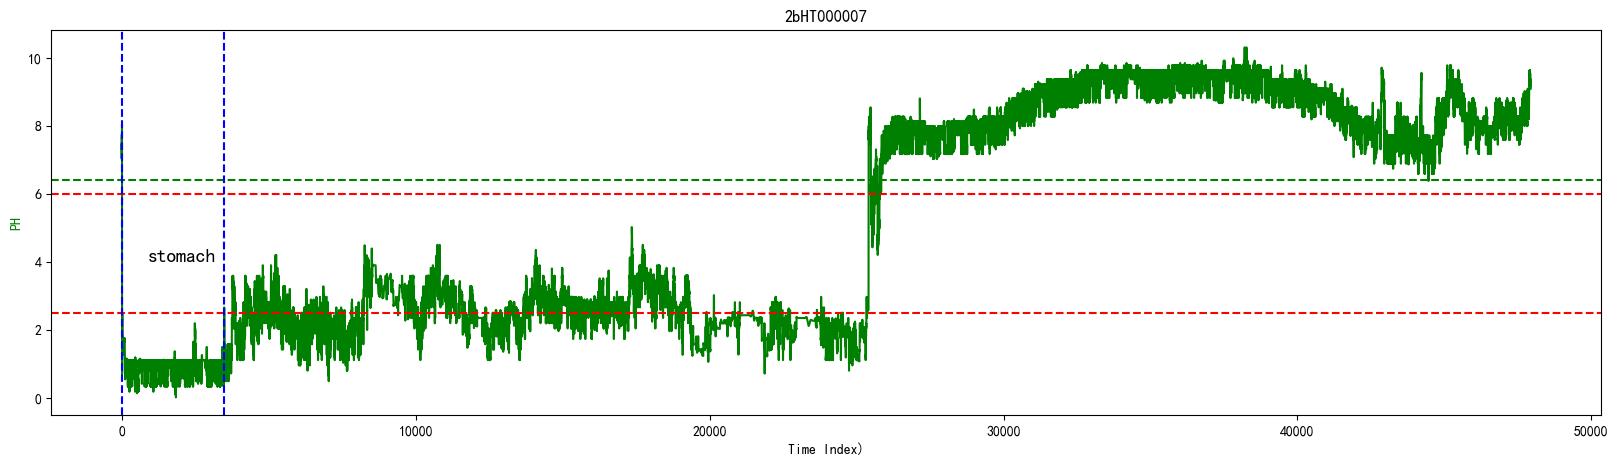

In [17]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots()

# ax2 = ax1.twinx()
# plt.ylim(0, 130)

# new_ticks = [0, 20, 40, 60 ,80] + list(range(90, 130, 10))
# plt.yticks(new_ticks)

ax1.plot(df.PH, color='g', label="PH")
# ax2.plot(df.Pressure, color='b', label="Pressure")

ax1.set_xlabel('Time Index)')
ax1.set_ylabel('PH', color='g')
# ax2.set_ylabel('Pressure', color='b')

ax1.axhline(y=2.5, color='r', linestyle='--')

ax1.axhline(y=6, color='r', linestyle='--')

ax1.axhline(y=6.4, color='g', linestyle='--')


ax1.axvline(x=stomach_start, color='b', linestyle='--')
ax1.axvline(x=stomach_end, color='b', linestyle='--')
ax1.text((stomach_start+stomach_end)/4, 4, "stomach", fontsize=14)

plt.title("2bHT000007")

# import matplotlib.pyplot as plt
# import pandas as pd

# # 假设你的 df 已经预处理好了
# # df = pd.read_csv('2bHT000007.txt', ...)  # 你的数据读取逻辑

# # 定义变量（你之前的截取位置）
# stomach_start = 15
# stomach_end = 3488

# # 绘图
# fig, ax1 = plt.subplots(figsize=(12, 6)) # 调整图大小更清晰

# # 1. 画左轴：pH
# ax1.plot(df.PH, color='g', linewidth=1.5, label="pH")
# ax1.set_xlabel('Time Index')
# ax1.set_ylabel('pH Value', color='g', fontsize=12)
# ax1.tick_params(axis='y', labelcolor='g')

# # 2. 画右轴：Pressure (取消注释并修改列名为你的压力列)
# # 注意：如果压力列名是中文"压力"或英文Pressure，要对应修改
# ax2 = ax1.twinx() 
# ax2.plot(df['Pressure'], color='b', linewidth=1.5, label="Pressure") # 列名是"Pressure"
# # ax2.plot(df.Pressure, color='b', linewidth=1.5, label="Pressure") # 如果是英文Pressure用这个
# ax2.set_ylabel('Pressure', color='b', fontsize=12)
# ax2.tick_params(axis='y', labelcolor='b')

# # 3. 绘制阈值线
# ax1.axhline(y=2.5, color='r', linestyle='--', alpha=0.7)
# ax1.axhline(y=6, color='r', linestyle='--', alpha=0.7)
# ax1.axhline(y=6.4, color='g', linestyle='--', alpha=0.7)

# # 4. 标记胃区间
# ax1.axvline(x=stomach_start, color='b', linestyle='--', alpha=0.8)
# ax1.axvline(x=stomach_end, color='b', linestyle='--', alpha=0.8)
# ax1.text((stomach_start + stomach_end) / 2, 4, "Stomach", fontsize=12, ha='center', bbox=dict(facecolor='white', alpha=0.6))

# # 5. 标题与图例
# plt.title("2bHT000007 - pH & Pressure Monitoring")
# fig.tight_layout() # 防止标签重叠
# plt.show()



信号可靠性较低，不能确定胶囊何时进入小肠，也不能确定何时离开小肠。所以只能通过时间信息截取一部分小肠的数据

胃在 1.2 小时后半清空，4-5个小时后，胃排空

我们从 4 小时后开始截取 4 小时的 数据
通过小肠的平均运输时间为 4 小时。进餐后平均5.4个小时，一餐中一半的食物残渣已从小肠排空。平均8.6小时后，小肠的排空完成

In [18]:
# np.argwhere(data.PH > 6.6)

In [19]:
# np.argwhere(data.PH < 6.4)

In [28]:
np.argwhere(np.asarray((df.PH > 6) & (df.PH < 6.4)))

array([[25487],
       [25488],
       [25490],
       [25552],
       [25554],
       [25559],
       [25560],
       [25561],
       [25562],
       [25563],
       [25564],
       [25565],
       [25566],
       [25567],
       [25568],
       [25569],
       [25585],
       [25587],
       [25594],
       [25595],
       [25597],
       [25598],
       [25604],
       [25605],
       [25606],
       [25607],
       [25611],
       [25614],
       [25615],
       [25616],
       [25618],
       [25620],
       [25623],
       [25627],
       [25629],
       [25631],
       [25634],
       [25635],
       [25636],
       [25640],
       [25641],
       [25642],
       [25643],
       [25783],
       [25784],
       [25785],
       [25804],
       [25805],
       [25806],
       [25807],
       [25811],
       [25830],
       [25831],
       [25832],
       [25833],
       [25834],
       [25835],
       [25836],
       [25837],
       [25838],
       [25839],
       [25840],
       [

In [21]:
small_intestine_start = stomach_end
small_intestine_end = 25841
(small_intestine_end - small_intestine_start) * 1.2 / 60 ** 2  # 共计 7.4 小时的数据，符合要求

7.451

Text(0.5, 1.0, '2bHT000007')

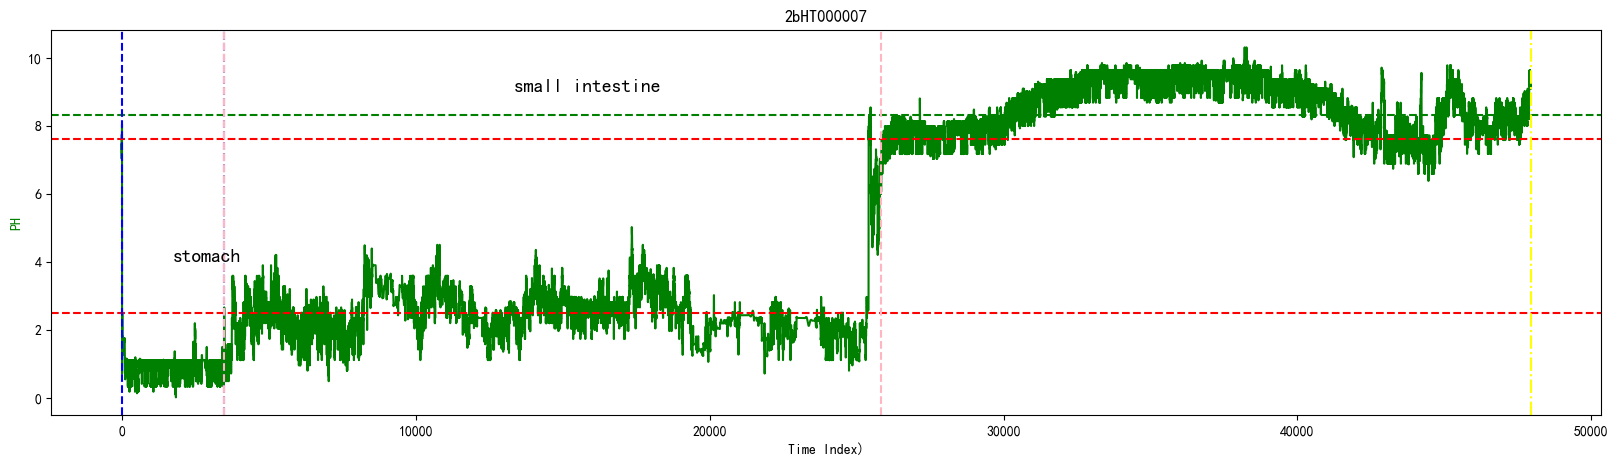

In [22]:
fig, ax1 = plt.subplots()

# ax2 = ax1.twinx()
# plt.ylim(0, 130)

# new_ticks = [0, 20, 40, 60 ,80] + list(range(90, 130, 10))
# plt.yticks(new_ticks)

ax1.plot(df.PH, color='g', label="PH")
# ax2.plot(df.Pressure, color='b', label="Pressure")

ax1.set_xlabel('Time Index)')
ax1.set_ylabel('PH', color='g')
# ax2.set_ylabel('Pressure', color='b')

ax1.axhline(y=2.5, color='r', linestyle='--')

ax1.axhline(y=7.6, color='r', linestyle='--')

ax1.axhline(y=8.3, color='g', linestyle='--')

ax1.axvline(x=len(df), color='yellow', linestyle='-.')

ax1.axvline(x=stomach_start, color='b', linestyle='--')
ax1.axvline(x=stomach_end, color='b', linestyle='--')
ax1.text((stomach_start+stomach_end)/2, 4, "stomach", fontsize=14)

ax1.axvline(x=small_intestine_start, color='lightpink', linestyle='--')
ax1.axvline(x=small_intestine_end, color='lightpink', linestyle='--')
ax1.text((small_intestine_start+small_intestine_end)/2.2, 9, "small intestine", fontsize=14)
plt.title("2bHT000007")

食物从胃和小肠然后进入结肠平均需要 6-8 个小时
由于在胃部停留了 1.53 小时，又截取了 5.0 小时的数据作为小肠部分的数据

在延迟 1 小时后剩下的数据应该是结肠部分的数据

In [23]:
colon_start = small_intestine_end + int(30 * 60 / 1.2)
(len(df)-colon_start) * 1.2 / 60 ** 2

6.864333333333333

Text(0.5, 1.0, '2bHT000007')

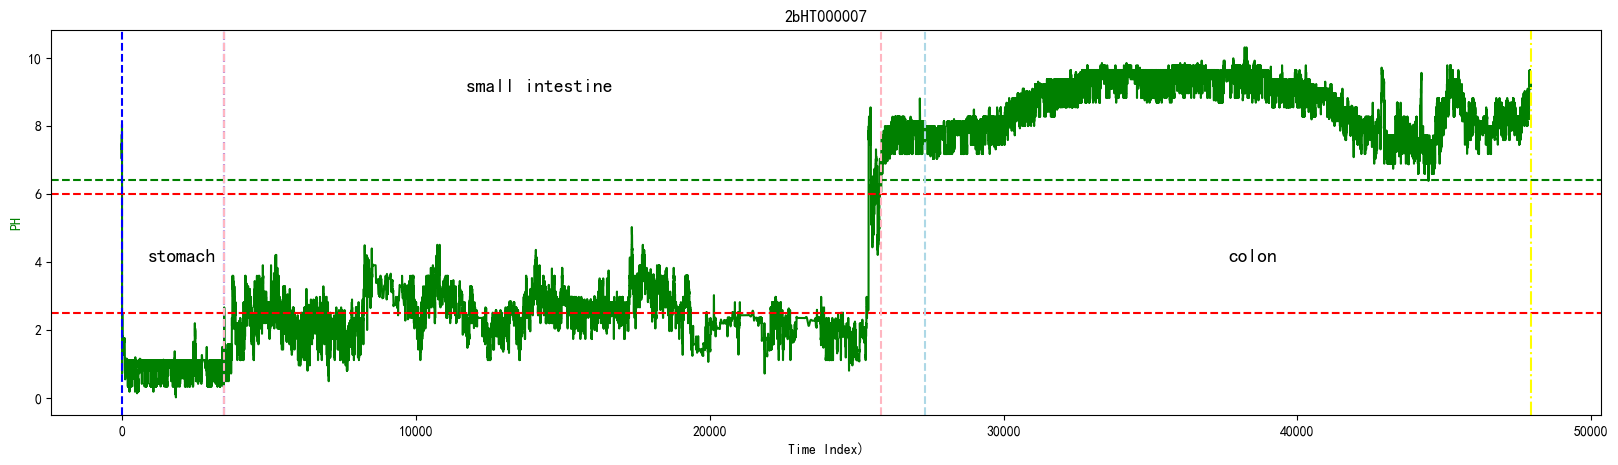

In [24]:
fig, ax1 = plt.subplots()

# ax2 = ax1.twinx()
# plt.ylim(0, 130)

# new_ticks = [0, 20, 40, 60 ,80] + list(range(90, 130, 10))
# plt.yticks(new_ticks)

ax1.plot(df.PH, color='g', label="PH")
# ax2.plot(df.Pressure, color='b', label="Pressure")

ax1.set_xlabel('Time Index)')
ax1.set_ylabel('PH', color='g')
# ax2.set_ylabel('Pressure', color='b')

ax1.axhline(y=2.5, color='r', linestyle='--')

ax1.axhline(y=6, color='r', linestyle='--')

ax1.axhline(y=6.4, color='g', linestyle='--')

ax1.axvline(x=len(df), color='yellow', linestyle='-.')

ax1.axvline(x=stomach_start, color='b', linestyle='--')
ax1.axvline(x=stomach_end, color='b', linestyle='--')
ax1.text((stomach_start+stomach_end)/4, 4, "stomach", fontsize=14)

ax1.axvline(x=small_intestine_start, color='lightpink', linestyle='--')
ax1.axvline(x=small_intestine_end, color='lightpink', linestyle='--')
ax1.text((small_intestine_start+small_intestine_end)/2.5, 9, "small intestine", fontsize=14)

ax1.axvline(x=colon_start, color='lightblue', linestyle='--')
ax1.text((colon_start+len(df))/2, 4, "colon", fontsize=14)
plt.title("2bHT000007")

In [25]:
# 结肠
colon_2bHT000007 = df.iloc[colon_start: len(df)].reset_index(drop=True)  # 记录了 6.86 小时的数据， 在结肠运转时间 1 - 6 h 的范围内

# 信号分离

由于记录的数据是 1.2s 记录 1 次数据
所以 数据的采样频率是大约是0.83 Hz
由于小波分解没进行一次，将数据分解为低频和高频两个部分
                                                               采样频率：0.83Hz
                                                               Nyquist频率: 0.415Hz
                                                       ca1: 0--0.2075Hz # cd1:0.2075--0.415Hz    高频干扰 和 呼吸
                                                ca2:0--0.10375HZ # cd2: 0.10375--0.2075Hz          呼吸和蠕动信号
                                        ca3:0--0.051875Hz # cd3: 0.051875--0.10375Hz               蠕动
                               ca4:0--0.0259375Hz # cd4: 0.0259375--0.051875Hz                     蠕动
                     ca5:0--0.01296875Hz # cd5: 0.01296875--0.0259375Hz                            蠕动，低频干扰
基础压力信号 ca6:0--0.006484375Hz # cd6: 0.006484375--0.01296875Hz                                   基础压力信号，低频干扰


呼吸信号的频率在 0.2--0.4Hz之间
- 位于 cd1 的频率太高，属于呼吸信号和高频干扰

蠕动压力信号的频率在 0.018--0.2Hz之间
- 位于 cd2 处的信号为蠕动压力信号和呼吸信号
- 位于 cd4-cd3 均为结肠蠕动压力波
- 位于 cd5 处的信号为蠕动压力信号和低频干扰
- 位于 cd6 和 ca6为胃肠道内基础压力信号

因此，我们需要对 cd2 和 cd5 进行降噪处理，然后将 cd5-cd2 合并得到蠕动压力信号

In [26]:
colon_2bHT000007

,Time,PH,Temperature,Pressure,New_Pressure
0,35147.65,7.784,36.549,100.072,100.072
1,35148.80,7.990,36.430,100.038,100.038
2,35149.94,7.990,36.466,100.221,100.221
3,35151.09,7.990,36.585,100.372,100.372
4,35152.23,7.990,36.430,100.060,100.060
...,...,...,...,...,...
20588,59297.20,9.363,36.549,99.884,99.884
20589,59298.34,9.363,35.349,99.821,99.821
20590,59299.48,9.363,35.276,99.810,99.810
20591,59300.62,9.363,35.349,99.252,99.252


In [27]:

# # 傅里叶变换绘制频谱图
# f = np.fft.fftfreq(len(colon_data.Peristalsis), 1/0.83)
# Y = np.fft.fft(colon_data.Peristalsis)
# plt.plot(f[:len(f)//2], np.abs(Y)[:len(f)//2])
# plt.title(f'频谱')
# plt.xlabel('频率 (Hz)')